In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

import pickle

In [7]:
# Load Dataset
df = pd.read_csv("../data/credit_date.csv")

df.head()

,Age,Income,LoanAmount,CreditScore,EmploymentYears,DebtToIncome,Default
0,59,53284.0,7552.0,653.0,14,0.32,0
1,49,93380.0,50538.0,659.0,2,0.19,0
2,35,54808.0,27503.0,645.0,18,0.44,1
3,28,29937.0,10556.0,650.0,9,0.26,0
4,41,55085.0,32146.0,696.0,27,0.20,1


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1000 non-null   int64  
 1   Income           1000 non-null   float64
 2   LoanAmount       1000 non-null   float64
 3   CreditScore      1000 non-null   float64
 4   EmploymentYears  1000 non-null   int64  
 5   DebtToIncome     1000 non-null   float64
 6   Default          1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


,Age,Income,LoanAmount,CreditScore,EmploymentYears,DebtToIncome,Default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.445000,61622.401000,21753.165000,700.684000,14.865000,0.293410,0.257000
std,11.499183,19638.646789,12069.118797,60.106713,8.561663,0.115496,0.437198
min,21.000000,20000.000000,3000.000000,550.000000,0.000000,0.100000,0.000000
25%,30.000000,47887.500000,12003.750000,658.000000,8.000000,0.190000,0.000000
50%,41.000000,61136.500000,19752.000000,701.500000,15.000000,0.290000,0.000000
75%,50.000000,74189.750000,29155.500000,741.000000,22.000000,0.390000,1.000000
max,59.000000,123862.000000,64396.000000,850.000000,29.000000,0.500000,1.000000


In [9]:
df.ffill(inplace=True)

In [10]:
X = df.drop("Default", axis=1)
y = df["Default"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Train XGBoost Model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=3.5  # Correctly placed here
)

model.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [18]:
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.3).astype(int)

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("--- Custom Threshold (0.3) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))


--- Custom Threshold (0.3) Results ---
Accuracy: 0.295

Confusion Matrix:
[[ 21 135]
 [  6  38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.13      0.23       156
           1       0.22      0.86      0.35        44

    accuracy                           0.29       200
   macro avg       0.50      0.50      0.29       200
weighted avg       0.65      0.29      0.26       200



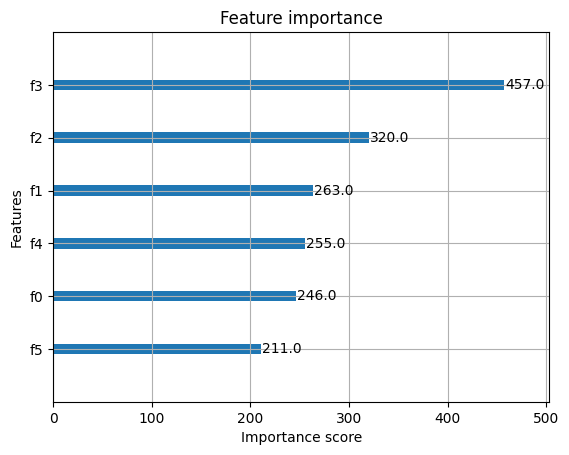

In [22]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()


In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.775

Confusion Matrix:
[[145  11]
 [ 34  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       156
           1       0.48      0.23      0.31        44

    accuracy                           0.78       200
   macro avg       0.64      0.58      0.59       200
weighted avg       0.74      0.78      0.74       200



In [24]:
with open("../model/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [25]:
sample = [[35,50000,10000,700,5,0.3]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("High Credit Risk" if prediction[0] == 1 else "Low Credit Risk")

High Credit Risk


C:\Users\Tanish_Gupta\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
